# 01 · Khảo sát bộ dữ liệu LongMemEval

## Notebook này trả lời

| Nhóm | Câu hỏi |
|---|---|
| **A · Cấu trúc** | Bao nhiêu câu mỗi loại? Mỗi câu có bao nhiêu phiên? Bằng chứng nằm ở đâu? |
| **B · Độ khó** | Bằng chứng cách câu hỏi bao lâu? Nhóm cập nhật kiến thức có mấy phiên bản? Câu hỏi và câu trả lời có trùng từ không? |
| **C · Chia dev/test** | Tách 150 câu để chỉnh tham số, khóa 350 câu còn lại |

In [1]:
# ============ Cấu hình ============
from pathlib import Path
import json, math, random, re, unicodedata
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

DATA_DIR = Path("/kaggle/input/notebooks/phongngtun/ss-agent-getdata")
OUT_DIR  = Path("/kaggle/working")
S_FILE   = DATA_DIR / "longmemeval_s.json"

DEV_RATIO = 0.30      # 30% vào dev
SEED      = 42        # cố định để chia lại vẫn ra y hệt

OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Dữ liệu :", S_FILE, "—", "CÓ" if S_FILE.exists() else "KHÔNG THẤY")

Dữ liệu : /kaggle/input/notebooks/phongngtun/ss-agent-getdata/longmemeval_s.json — CÓ


In [2]:
P1, P2, P3 = "#5B57C9", "#C77F06", "#00908C"   
INK, INK2, MUTED, GRID = "#1A1A1A", "#4A4A4A", "#767676", "#E4E4E4"

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 180, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": GRID, "axes.linewidth": 0.8,
    "axes.labelcolor": INK2, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlecolor": INK, "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": GRID, "grid.linewidth": 0.7, "legend.frameon": False,
    "font.size": 10, "text.color": INK2,
})

def finish(ax, title, sub=None, ygrid=True):
    """Đặt tiêu đề, bật lưới mờ theo trục y, dọn khung."""
    ax.set_title(title)
    if sub:
        ax.text(0, 1.02, sub, transform=ax.transAxes, fontsize=9,
                color=MUTED, va="bottom")
    if ygrid:
        ax.set_axisbelow(True); ax.grid(axis="y")
    return ax

def save(fig, name):
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"{name}.png", bbox_inches="tight")
    print("đã lưu:", name + ".png")

In [3]:
# ============ Nạp dữ liệu ============
with open(S_FILE, encoding="utf-8") as f:
    data = json.load(f)

print(f"{len(data)} instance")
print("Các trường của một instance:")
for k, v in data[0].items():
    kind = type(v).__name__
    size = f" (len={len(v)})" if isinstance(v, (list, dict, str)) else ""
    print(f"  {k:24s} {kind}{size}")

500 instance
Các trường của một instance:
  question_id              str (len=8)
  question_type            str (len=19)
  question                 str (len=32)
  question_date            str (len=22)
  answer                   str (len=23)
  answer_session_ids       list (len=1)
  haystack_dates           list (len=53)
  haystack_session_ids     list (len=53)
  haystack_sessions        list (len=53)


In [4]:
# ============ Làm phẳng thành bảng một dòng / một câu hỏi ============
def n_turns(sess):
    """Một phiên là list các lượt {role, content, (has_answer)}."""
    return len(sess) if isinstance(sess, list) else 0

def approx_tokens(text):
    """Ước lượng thô: ~4 ký tự / token cho tiếng Anh.
    Notebook 02 sẽ đo bằng tokenizer thật; ở đây chỉ cần để so tương đối."""
    return len(text) / 4.0

rows = []
for ex in data:
    sessions  = ex["haystack_sessions"]
    sess_ids  = ex["haystack_session_ids"]
    ans_ids   = set(ex.get("answer_session_ids") or [])

    # vị trí (0..1) của các phiên chứa bằng chứng trong dãy
    pos = [i / max(len(sess_ids) - 1, 1)
           for i, sid in enumerate(sess_ids) if sid in ans_ids]

    # đếm lượt có cờ has_answer
    n_ans_turns = 0
    for sess in sessions:
        for t in (sess if isinstance(sess, list) else []):
            if isinstance(t, dict) and t.get("has_answer"):
                n_ans_turns += 1

    all_text = " ".join(
        t.get("content", "") for sess in sessions
        for t in (sess if isinstance(sess, list) else []) if isinstance(t, dict)
    )

    rows.append({
        "question_id":   ex["question_id"],
        "question_type": ex["question_type"],
        "is_abstention": ex["question_type"].endswith("_abs"),
        "base_type":     ex["question_type"].replace("_abs", ""),
        "n_sessions":    len(sessions),
        "n_turns":       sum(n_turns(s) for s in sessions),
        "n_evid_sess":   len(ans_ids),
        "n_evid_turns":  n_ans_turns,
        "evid_pos_mean": float(np.mean(pos)) if pos else np.nan,
        "evid_pos_min":  float(np.min(pos))  if pos else np.nan,
        "approx_tokens": approx_tokens(all_text),
        "question":      ex["question"],
        "answer":        str(ex.get("answer", "")),
        "question_date": ex.get("question_date", ""),
    })

df = pd.DataFrame(rows)
print(df.shape)
df.head(3)

(500, 14)


,question_id,question_type,is_abstention,base_type,n_sessions,n_turns,n_evid_sess,n_evid_turns,evid_pos_mean,evid_pos_min,approx_tokens,question,answer,question_date
0,e47becba,single-session-user,False,single-session-user,53,550,1,2,0.980769,0.980769,121510.75,What degree did I graduate with?,Business Administration,2023/05/30 (Tue) 23:40
1,118b2229,single-session-user,False,single-session-user,45,485,1,1,0.159091,0.159091,121129.25,How long is my daily commute to work?,45 minutes each way,2023/05/30 (Tue) 20:36
2,51a45a95,single-session-user,False,single-session-user,50,529,1,1,0.857143,0.857143,125523.25,Where did I redeem a $5 coupon on coffee creamer?,Target,2023/05/30 (Tue) 20:42


## A1 · Bao nhiêu câu mỗi loại

Quan trọng vì **accuracy gộp sẽ bị loại đông nhất chi phối**. Nếu một loại chiếm 30%
số câu thì hệ giỏi riêng loại đó đã kéo điểm tổng lên đáng kể — đó là lý do báo cáo
dùng macro-average chứ không gộp.

đã lưu: a1_phan_bo_loai.png


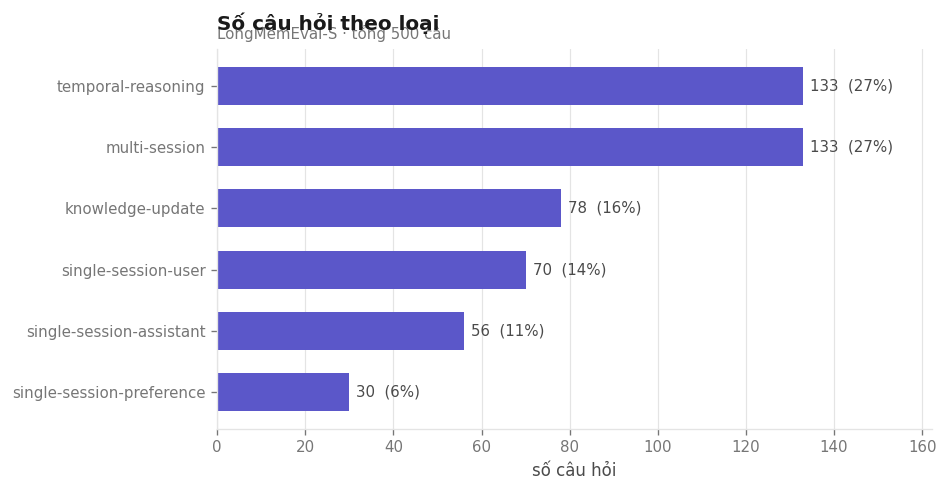

,n,pct
question_type,,
knowledge-update,78,15.6
multi-session,133,26.6
single-session-assistant,56,11.2
single-session-preference,30,6.0
single-session-user,70,14.0
temporal-reasoning,133,26.6


In [5]:
cnt = df["question_type"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.barh(cnt.index, cnt.values, color=P1, height=0.62)
for b, v in zip(bars, cnt.values):                      # nhãn trực tiếp
    ax.text(v + max(cnt.values) * 0.012, b.get_y() + b.get_height() / 2,
            f"{v}  ({v / len(df):.0%})", va="center", fontsize=9, color=INK2)
ax.set_xlim(0, max(cnt.values) * 1.22)
ax.set_xlabel("số câu hỏi")
finish(ax, "Số câu hỏi theo loại",
       f"LongMemEval-S · tổng {len(df)} câu", ygrid=False)
ax.grid(axis="x"); ax.set_axisbelow(True)
save(fig, "a1_phan_bo_loai"); plt.show()

display(df.groupby("question_type").size().rename("n").to_frame()
          .assign(pct=lambda d: (d.n / len(df) * 100).round(1)))

## A2 · Mỗi câu hỏi phải lục qua bao nhiêu thứ

Đây là dữ liệu để dự trù chi phí nạp. Tổng số **phiên** trên toàn bộ tập nhân với
số lời gọi mỗi phiên chính là hạn mức API cần.

đã lưu: a2_kich_thuoc.png


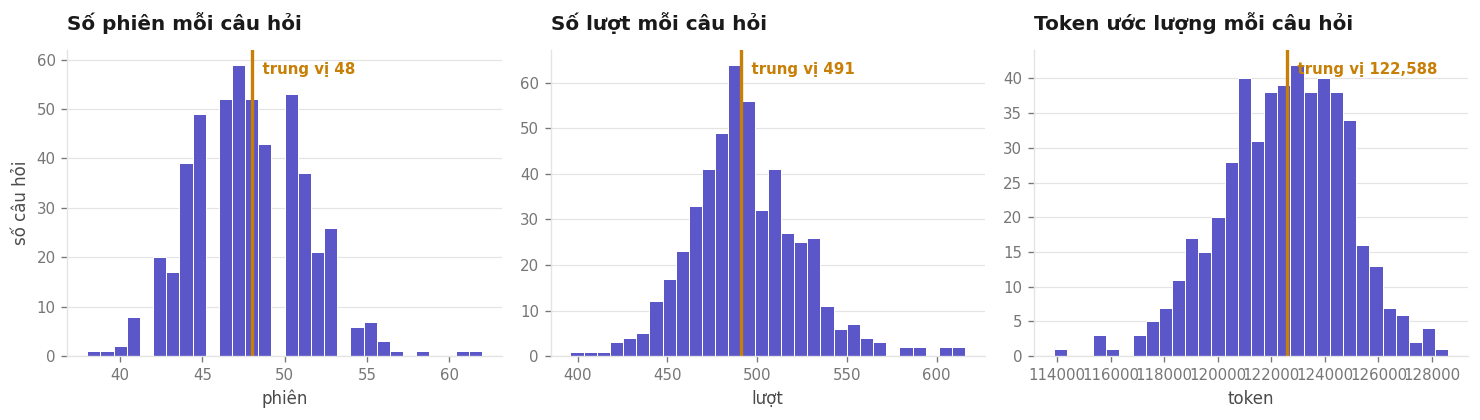

Tổng số phiên phải nạp nếu chạy hết 500 câu: 23,867
→ Gom cả phiên vào 1 lời gọi thì vẫn ~23,867 lời gọi.
→ Hạn mức miễn phí 1.500 lượt/ngày ≈ 16 ngày. Phải dùng mô hình chạy local cho pha nạp.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))

for ax, col, title, unit in [
    (axes[0], "n_sessions", "Số phiên mỗi câu hỏi", "phiên"),
    (axes[1], "n_turns",    "Số lượt mỗi câu hỏi",  "lượt"),
    (axes[2], "approx_tokens", "Token ước lượng mỗi câu hỏi", "token"),
]:
    v = df[col].dropna()
    ax.hist(v, bins=30, color=P1, edgecolor="white", linewidth=0.6)
    med = v.median()
    ax.axvline(med, color=P2, linewidth=2)
    ax.text(med, ax.get_ylim()[1] * 0.92, f"  trung vị {med:,.0f}",
            color=P2, fontsize=9, fontweight="bold")
    ax.set_xlabel(unit)
    finish(ax, title)

axes[0].set_ylabel("số câu hỏi")
save(fig, "a2_kich_thuoc"); plt.show()

tong_phien = int(df["n_sessions"].sum())
print(f"Tổng số phiên phải nạp nếu chạy hết 500 câu: {tong_phien:,}")
print(f"→ Gom cả phiên vào 1 lời gọi thì vẫn ~{tong_phien:,} lời gọi.")
print(f"→ Hạn mức miễn phí 1.500 lượt/ngày ≈ {tong_phien/1500:.0f} ngày. "
      f"Phải dùng mô hình chạy local cho pha nạp.")

## A3 · Bằng chứng nằm ở đâu

Hai câu hỏi:

- **Bao nhiêu phiên chứa bằng chứng?** Nếu phần lớn chỉ 1 phiên thì `QueryPlanner`
  (tách truy vấn con) ít đất dụng võ — số này quyết định có đáng làm hay không.
- **Bằng chứng nằm đầu hay cuối dãy?** Nếu hay nằm cuối thì thiên lệch gần-đây sẽ
  "ăn gian" điểm, và phải biết trước để không nhầm đó là hệ chạy tốt.

đã lưu: a3_vi_tri_bang_chung.png


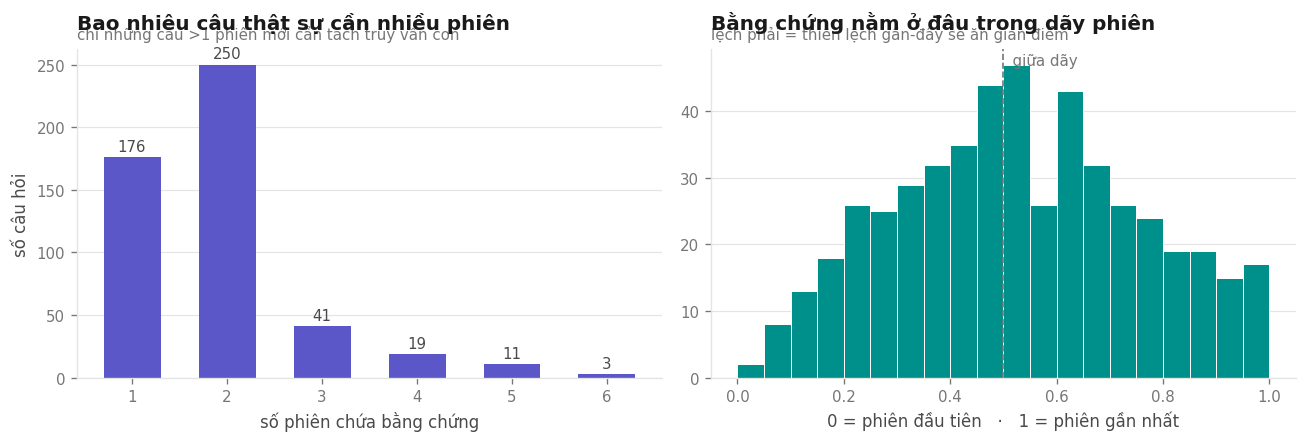

64.8% số câu có bằng chứng nằm ở nhiều hơn một phiên.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

# trái — số phiên chứa bằng chứng
c = df["n_evid_sess"].value_counts().sort_index()
bars = axes[0].bar(c.index.astype(str), c.values, color=P1, width=0.6)
for b, v in zip(bars, c.values):
    axes[0].text(b.get_x() + b.get_width() / 2, v + max(c.values) * 0.02,
                 f"{v}", ha="center", fontsize=9, color=INK2)
axes[0].set_xlabel("số phiên chứa bằng chứng"); axes[0].set_ylabel("số câu hỏi")
finish(axes[0], "Bao nhiêu câu thật sự cần nhiều phiên",
       "chỉ những câu >1 phiên mới cần tách truy vấn con")

# phải — vị trí tương đối
pos = df["evid_pos_mean"].dropna()
axes[1].hist(pos, bins=20, range=(0, 1), color=P3, edgecolor="white", linewidth=0.6)
axes[1].axvline(0.5, color=MUTED, linewidth=1, linestyle="--")
axes[1].text(0.5, axes[1].get_ylim()[1] * 0.95, "  giữa dãy",
             fontsize=9, color=MUTED)
axes[1].set_xlabel("0 = phiên đầu tiên   ·   1 = phiên gần nhất")
finish(axes[1], "Bằng chứng nằm ở đâu trong dãy phiên",
       "lệch phải = thiên lệch gần-đây sẽ ăn gian điểm")

save(fig, "a3_vi_tri_bang_chung"); plt.show()

multi = (df["n_evid_sess"] > 1).mean()
print(f"{multi:.1%} số câu có bằng chứng nằm ở nhiều hơn một phiên.")

## B1 · Bằng chứng cách câu hỏi bao lâu

Với nhóm `knowledge-update` thì đây là biến quan trọng nhất: khoảng cách càng xa,
càng nhiều phiên nhiễu chen giữa hai phiên bản của cùng một fact.

/tmp/ipykernel_58/2228681362.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([gdf.loc[gdf.base_type == t, "days"] for t in order],


đã lưu: b1_khoang_cach_thoi_gian.png


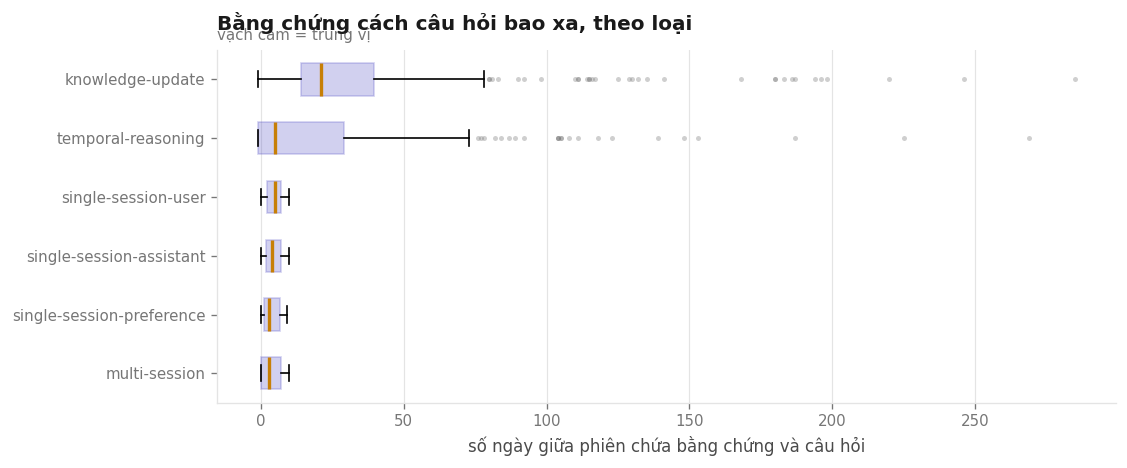

,count,25%,50%,75%,max
base_type,,,,,
knowledge-update,156.0,14.0,21.0,40.0,285.0
multi-session,344.0,0.0,3.0,7.0,10.0
single-session-assistant,56.0,2.0,4.0,7.0,10.0
single-session-preference,30.0,1.0,3.0,7.0,9.0
single-session-user,70.0,2.0,5.0,7.0,10.0
temporal-reasoning,292.0,-1.0,5.0,29.0,269.0


In [8]:
def to_ts(s):
    for fmt in ("%Y/%m/%d (%a) %H:%M", "%Y/%m/%d", "%Y-%m-%d %H:%M", "%Y-%m-%d"):
        try:
            return pd.to_datetime(s, format=fmt)
        except Exception:
            pass
    return pd.to_datetime(s, errors="coerce")

gaps = []
for ex in data:
    q_ts = to_ts(ex.get("question_date", ""))
    if pd.isna(q_ts):
        continue
    ans_ids = set(ex.get("answer_session_ids") or [])
    for sid, d in zip(ex["haystack_session_ids"], ex.get("haystack_dates", [])):
        if sid in ans_ids:
            s_ts = to_ts(d)
            if not pd.isna(s_ts):
                gaps.append({"question_type": ex["question_type"],
                             "base_type": ex["question_type"].replace("_abs", ""),
                             "days": (q_ts - s_ts).days})

gdf = pd.DataFrame(gaps)
if len(gdf):
    order = gdf.groupby("base_type")["days"].median().sort_values().index.tolist()
    fig, ax = plt.subplots(figsize=(9.5, 4))
    bp = ax.boxplot([gdf.loc[gdf.base_type == t, "days"] for t in order],
                    labels=order, vert=False, widths=0.55, patch_artist=True,
                    medianprops=dict(color=P2, linewidth=2),
                    flierprops=dict(marker="o", markersize=3,
                                    markerfacecolor=MUTED, markeredgecolor="none",
                                    alpha=0.35))
    for patch in bp["boxes"]:
        patch.set_facecolor(P1); patch.set_alpha(0.28); patch.set_edgecolor(P1)
    ax.set_xlabel("số ngày giữa phiên chứa bằng chứng và câu hỏi")
    finish(ax, "Bằng chứng cách câu hỏi bao xa, theo loại",
           "vạch cam = trung vị", ygrid=False)
    ax.grid(axis="x"); ax.set_axisbelow(True)
    save(fig, "b1_khoang_cach_thoi_gian"); plt.show()
    display(gdf.groupby("base_type")["days"].describe()[["count","25%","50%","75%","max"]].round(0))
else:
    print("Không đọc được định dạng ngày — kiểm tra lại hàm to_ts().")

## B2 · Nhìn kỹ nhóm `knowledge-update`

Đây là nhóm kiểm chứng trực tiếp thiết kế slot + `seq`. Xem vài ví dụ thật thay vì
ví dụ N5→N4 tự bịa.

In [9]:
ku = [ex for ex in data if ex["question_type"].startswith("knowledge-update")]
print(f"{len(ku)} câu nhóm knowledge-update\n")

for ex in ku[:3]:
    ans_ids = set(ex.get("answer_session_ids") or [])
    print("─" * 88)
    print("HỎI   :", ex["question"])
    print("ĐÁP   :", ex.get("answer"))
    print(f"BẰNG CHỨNG nằm ở {len(ans_ids)} phiên:")
    for sid, d, sess in zip(ex["haystack_session_ids"], ex.get("haystack_dates", []),
                            ex["haystack_sessions"]):
        if sid not in ans_ids:
            continue
        for t in (sess if isinstance(sess, list) else []):
            if isinstance(t, dict) and t.get("has_answer"):
                txt = t.get("content", "").strip().replace("\n", " ")
                print(f"   [{d}] {t.get('role','?'):9s} {txt[:150]}")
    print()

78 câu nhóm knowledge-update

────────────────────────────────────────────────────────────────────────────────────────
HỎI   : What was my personal best time in the charity 5K run?
ĐÁP   : 25 minutes and 50 seconds (or 25:50)
BẰNG CHỨNG nằm ở 2 phiên:
   [2023/05/23 (Tue) 13:01] user      That's really helpful, thanks! I've been doing some running lately, and I'm happy to say that I recently set a personal best time in a charity 5K run 
   [2023/05/30 (Tue) 13:53] user      I'm training for another charity 5K run coming up and I was wondering if you could give me some tips on how to improve my endurance. By the way, I'm h

────────────────────────────────────────────────────────────────────────────────────────
HỎI   : How many Korean restaurants have I tried in my city?
ĐÁP   : four
BẰNG CHỨNG nằm ở 2 phiên:
   [2023/08/11 (Fri) 09:09] user      By the way, speaking of noodles, have you tried any good Korean restaurants in your city lately? I've tried three different ones recently, and

## B3 · Câu hỏi và câu chứa đáp án có trùng từ không

**Dự báo được đóng góp của BM25 trước khi chạy hệ thống.** Trùng từ cao → BM25 bắt
được; trùng thấp → phải dựa vào vector. Đây là bằng chứng bằng số cho quyết định
dùng truy xuất lai, chứ không phải lý lẽ suông.

đã lưu: b3_trung_tu_vung.png


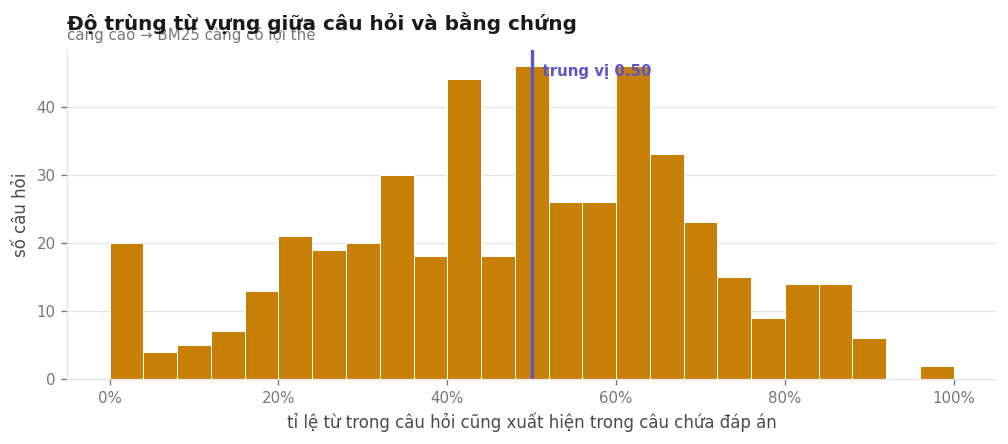

Trung vị 50.0% từ của câu hỏi xuất hiện lại trong câu chứa đáp án.
10.2% số câu có độ trùng dưới 20% — nhóm này chỉ vector mới tìm được.


In [11]:
STOP = set("""a an the is are was were be been being of in on at to for with and or
but if then than that this these those i you he she it we they my your his her its
our their me him them do does did have has had can could will would shall should
may might must not no nor so such as by from about into over after before""".split())

def toks(s):
    return [w for w in re.findall(r"[a-z0-9]+", s.lower())
            if len(w) > 1 and w not in STOP]

ov = []
for ex in data:
    q = set(toks(ex["question"]))
    if not q:
        continue
    ans_ids = set(ex.get("answer_session_ids") or [])
    ev = []
    for sid, sess in zip(ex["haystack_session_ids"], ex["haystack_sessions"]):
        if sid in ans_ids:
            for t in (sess if isinstance(sess, list) else []):
                if isinstance(t, dict) and t.get("has_answer"):
                    ev += toks(t.get("content", ""))
    if not ev:
        continue
    ev = set(ev)
    ov.append({"base_type": ex["question_type"].replace("_abs", ""),
               "jaccard": len(q & ev) / len(q | ev),
               "cover":   len(q & ev) / len(q)})

odf = pd.DataFrame(ov)

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.hist(odf["cover"], bins=25, range=(0, 1), color=P2,
        edgecolor="white", linewidth=0.6)
med = odf["cover"].median()
ax.axvline(med, color=P1, linewidth=2)
ax.text(med, ax.get_ylim()[1]*0.92, f"  trung vị {med:.2f}",
        color=P1, fontsize=9, fontweight="bold")
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("tỉ lệ từ trong câu hỏi cũng xuất hiện trong câu chứa đáp án")
ax.set_ylabel("số câu hỏi")
finish(ax, "Độ trùng từ vựng giữa câu hỏi và bằng chứng",
       "càng cao → BM25 càng có lợi thế")
save(fig, "b3_trung_tu_vung"); plt.show()

print(f"Trung vị {med:.1%} từ của câu hỏi xuất hiện lại trong câu chứa đáp án.")
print(f"{(odf['cover'] < 0.2).mean():.1%} số câu có độ trùng dưới 20% "
      f"— nhóm này chỉ vector mới tìm được.")

## C · Chia `dev` / `test`

**Chạy đúng một lần, rồi commit `split.json` và không đụng vào nữa.**

- `dev` (~30%): quét `k`, `τ`, ngưỡng ghép slot, thử cách viết lời nhắc — nhìn bao nhiêu lần cũng được
- `test` (~70%): khóa lại, mở đúng một lần ở tuần 7

Chia **phân tầng** theo loại câu hỏi để mỗi loại giữ đúng tỉ lệ ở cả hai bên.

In [12]:
random.seed(SEED)

by_type = defaultdict(list)
for ex in data:
    by_type[ex["question_type"]].append(ex["question_id"])

dev, test = [], []
for qtype, ids in sorted(by_type.items()):
    ids = sorted(ids)              # sắp trước khi trộn → tất định
    random.shuffle(ids)
    n_dev = round(len(ids) * DEV_RATIO)
    dev  += ids[:n_dev]
    test += ids[n_dev:]

split = {"seed": SEED, "dev_ratio": DEV_RATIO,
         "dev": sorted(dev), "test": sorted(test)}
with open(OUT_DIR / "split.json", "w") as f:
    json.dump(split, f, indent=2)

# kiểm tra phân tầng có giữ đúng tỉ lệ không
chk = (df.assign(split=np.where(df.question_id.isin(dev), "dev", "test"))
         .pivot_table(index="question_type", columns="split",
                      values="question_id", aggfunc="count", fill_value=0))
chk["dev %"] = (chk["dev"] / (chk["dev"] + chk["test"]) * 100).round(1)
display(chk)

print(f"\ndev  = {len(dev)} câu")
print(f"test = {len(test)} câu   ← KHÓA LẠI, mở đúng một lần ở tuần 7")
print("Đã lưu: /kaggle/working/split.json — commit file này vào git.")

split,dev,test,dev %
question_type,,,
knowledge-update,23,55,29.5
multi-session,40,93,30.1
single-session-assistant,17,39,30.4
single-session-preference,9,21,30.0
single-session-user,21,49,30.0
temporal-reasoning,40,93,30.1



dev  = 150 câu
test = 350 câu   ← KHÓA LẠI, mở đúng một lần ở tuần 7
Đã lưu: /kaggle/working/split.json — commit file này vào git.


## Tổng kết — số liệu đưa thẳng vào báo cáo

In [13]:
summary = pd.DataFrame({
    "Tổng số câu hỏi":            [len(df)],
    "Số loại câu hỏi":            [df.question_type.nunique()],
    "Phiên / câu (trung vị)":     [int(df.n_sessions.median())],
    "Lượt / câu (trung vị)":      [int(df.n_turns.median())],
    "Tổng số phiên phải nạp":     [int(df.n_sessions.sum())],
    "Câu cần >1 phiên bằng chứng":[f"{(df.n_evid_sess > 1).mean():.1%}"],
    "Trùng từ vựng (trung vị)":   [f"{odf['cover'].median():.1%}"],
    "dev / test":                 [f"{len(dev)} / {len(test)}"],
}).T.rename(columns={0: "giá trị"})
display(summary)

df.to_parquet(OUT_DIR / "questions.parquet", index=False)
summary.to_csv(OUT_DIR / "summary.csv")
print("\nĐã lưu questions.parquet và summary.csv vào /kaggle/working/")
print("→ Bấm Save Version để giữ lại, rồi gắn output này làm input cho notebook 02.")

,giá trị
Tổng số câu hỏi,500
Số loại câu hỏi,6
Phiên / câu (trung vị),48
Lượt / câu (trung vị),491
Tổng số phiên phải nạp,23867
Câu cần >1 phiên bằng chứng,64.8%
Trùng từ vựng (trung vị),50.0%
dev / test,150 / 350



Đã lưu questions.parquet và summary.csv vào /kaggle/working/
→ Bấm Save Version để giữ lại, rồi gắn output này làm input cho notebook 02.
